<h2>Exercise 02: Bar</h2>

In [1]:
import pandas as pd 
import sqlite3

### 1. Preprocessing 

In [48]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [50]:
df = pd.io.sql.read_sql(
    """
    SELECT
        timestamp    
    FROM checker
    WHERE uid LIKE "user_%"
    """,
    conn,
    parse_dates=["timestamp"]
)

df

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [51]:
df["hour"] = df["timestamp"].dt.hour

In [52]:
df

,timestamp,hour
0,2020-04-17 05:19:02.744528,5
1,2020-04-17 05:22:35.249331,5
2,2020-04-17 05:22:45.549397,5
3,2020-04-17 05:34:14.691200,5
4,2020-04-17 05:34:24.422370,5
...,...,...
3202,2020-05-21 20:19:06.872761,20
3203,2020-05-21 20:22:41.785725,20
3204,2020-05-21 20:22:41.877806,20
3205,2020-05-21 20:37:00.129678,20


```Night is from 0:00:00 to 03:59:59```

```Morning is from 04:00:00 to 09:59:59```

```Afternoon is from 10:00:00 to 16:59:59```

```Evening is from 17:00:00 to 23:59:59```

In [53]:
bins = [0, 4, 10, 17, 24]
labels = ["night", "morning", "afternoon", "evening"]

df["daytime"] = pd.cut(
    df["hour"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df

,timestamp,hour,daytime
0,2020-04-17 05:19:02.744528,5,morning
1,2020-04-17 05:22:35.249331,5,morning
2,2020-04-17 05:22:45.549397,5,morning
3,2020-04-17 05:34:14.691200,5,morning
4,2020-04-17 05:34:24.422370,5,morning
...,...,...,...
3202,2020-05-21 20:19:06.872761,20,evening
3203,2020-05-21 20:22:41.785725,20,evening
3204,2020-05-21 20:22:41.877806,20,evening
3205,2020-05-21 20:37:00.129678,20,evening


In [54]:
df["date"] = df["timestamp"].dt.date

In [55]:
df_grouped = (
    df.groupby(["date", "daytime"])
      .size()
      .reset_index(name="commits")
)

df_grouped


,date,daytime,commits
0,2020-04-17,morning,13
1,2020-04-17,afternoon,10
2,2020-04-18,morning,1
3,2020-04-18,afternoon,33
4,2020-04-18,evening,35
...,...,...,...
85,2020-05-20,afternoon,11
86,2020-05-20,evening,10
87,2020-05-21,morning,1
88,2020-05-21,afternoon,27


In [60]:
df_pivot = df_pivot[['night','morning','afternoon','evening']]

In [61]:
df_pivot

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,NaN,13.0,10.0,NaN
2020-04-18,NaN,1.0,33.0,35.0
2020-04-19,2.0,4.0,16.0,11.0
2020-04-20,NaN,NaN,12.0,13.0
2020-04-21,NaN,NaN,NaN,25.0
2020-04-22,NaN,NaN,4.0,24.0
2020-04-23,2.0,6.0,15.0,20.0
2020-04-24,NaN,NaN,4.0,12.0
2020-04-25,1.0,21.0,33.0,49.0


### 2. Vizualization

<Axes: title={'center': 'Commits per day'}, xlabel='date'>

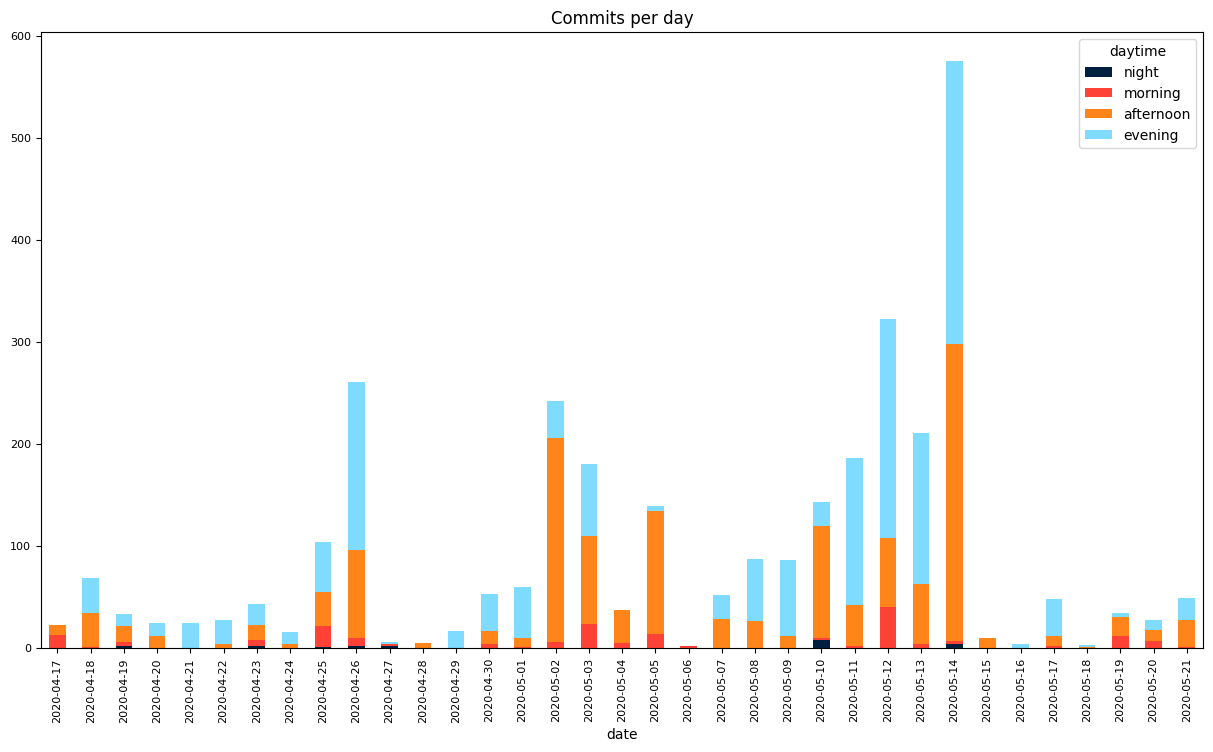

In [62]:
df_pivot.plot.bar(
    figsize=(15,8),
    fontsize=8,
    title="Commits per day",
    color=['#001f3f', '#ff4136', '#ff851b', '#7fdbff'],
    stacked=True
)

<h3> Выполняют чаще всего днем и вчером</h3>

<h3>2020-05-14  чаще всего выполняли вечером</h3>